# 能源需求预测 — 07 增强全局模型 + 业务化预测

两部分:
- **A. 增强全局模型**:全局联合模型从 TiDE 换成 **GRU(分位数输出)**,并加入**区域静态特征**
  (纬度/经度/人口代理/Tiwai 大工业负荷标记),与 nb06 的全局 TiDE 对比 CRPS。
- **B. 业务化预测**:接 **Open-Meteo 预报 API** 取未来天气 + **EMI 最新需求**,用增强后的模型
  输出未来 1 天 & 1 周的**带区间**需求预测(各区 + 全国),并给出 **±5°C 天气情景**。

这一步把前面的回测研究变成**面向当前时刻的前瞻预测**,直接对应项目目标
"不同天气情景下的能源需求预测"。

## A0. 设置:5 区 + 逐区标准化 + 区域静态特征

In [1]:
import sys, warnings, time, io
from functools import reduce
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import requests, holidays
import torch
from torch.utils.data import TensorDataset

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import forecast_utils as fu
import deep

warnings.filterwarnings("ignore")
%matplotlib inline
torch.manual_seed(0); np.random.seed(0)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
RAW = ROOT / "data" / "raw"; HDRS = {"User-Agent": "Mozilla/5.0 (ds-project)"}

ZONES = ["UNI", "CNI", "LNI", "USI", "LSI"]
LOC = {"UNI": (-36.85, 174.76), "CNI": (-37.79, 175.28), "LNI": (-41.29, 174.78),
       "USI": (-43.53, 172.63), "LSI": (-45.87, 170.50)}
TIWAI = {"UNI": 0, "CNI": 0, "LNI": 0, "USI": 0, "LSI": 1}   # Tiwai Pt smelter in LSI
TRAIN_END = "2024-12-31"
L, H = 336, fu.H_WEEK
HORIZONS = (fu.H_DAY, fu.H_WEEK)
QLEVELS = list(np.round(np.arange(0.05, 0.96, 0.05), 2))
I10, I50, I90 = QLEVELS.index(0.1), QLEVELS.index(0.5), QLEVELS.index(0.9)
ALPHA, TZ = 0.2, fu.TZ
T, FEATS = fu.TARGET, fu.COVARIATES
NW = len(fu.WEATHER_FEATS)

dfs = {z: fu.load_zone(z) for z in ZONES}
common = reduce(lambda a, b: a.intersection(b), [d.index for d in dfs.values()])
dfs = {z: d.loc[common] for z, d in dfs.items()}
TL = int((common <= pd.Timestamp(TRAIN_END, tz="UTC")).sum())
origins = fu.make_origins(dfs[ZONES[0]], "2025-01-01", max_h=H, step_days=14)

# static features (lat, lon, pop-proxy=mean train demand, is_tiwai), standardized across zones
raw_static = np.array([[*LOC[z], dfs[z][T].values[:TL].mean(), TIWAI[z]] for z in ZONES], "f4")
sm, ss = raw_static.mean(0), raw_static.std(0) + 1e-8
static_std = (raw_static - sm) / ss
NSTAT = static_std.shape[1]; NF = len(FEATS) + NSTAT

Z = {}
for j, z in enumerate(ZONES):
    d = dfs[z]; y = d[T].values.astype("f4"); X = d[FEATS].values.astype("f4")
    ymu, ysd = y[:TL].mean(), y[:TL].std(); xmu, xsd = X[:TL].mean(0), X[:TL].std(0) + 1e-8
    ys = (y - ymu) / ysd; Xs = (X - xmu) / xsd
    st = np.tile(static_std[j], (len(ys), 1)).astype("f4")
    Z[z] = dict(ys=ys, Xstat=np.concatenate([Xs, st], 1), ymu=ymu, ysd=ysd,
                xmu=xmu, xsd=xsd, static=static_std[j])
print(f"common={len(common)} TL={TL} origins={len(origins)} | n_feats={NF} | dev={DEV}")

common=129976 TL=105186 origins=37 | n_feats=20 | dev=cuda


## A1. 训练增强全局模型(GRU + 静态特征,分位数输出)

把 5 区窗口池化(协变量已含区域静态特征),训练**一个** `Seq2Seq(GRU, n_out=19)`,pinball 损失。

In [2]:
def qloss(p, t):
    return deep.quantile_loss(p, t, QLEVELS)

def pooled(starts):
    Xp, Xf, Y = [], [], []
    for z in ZONES:
        a, b, c = deep.make_windows(Z[z]["ys"], Z[z]["Xstat"], starts, L, H)
        Xp.append(a); Xf.append(b); Y.append(c)
    return torch.cat(Xp), torch.cat(Xf), torch.cat(Y)

starts = np.arange(L - 1, TL - H, 16)
nv = int(len(starts) * 0.15)
g_tr = TensorDataset(*pooled(starts[:-nv])); g_va = list(pooled(starts[-nv:]))
print("pooled windows:", len(g_tr))
torch.manual_seed(0)
t0 = time.time()
gmodel = deep.train_torch(deep.Seq2Seq(NF, "GRU", 96, n_out=len(QLEVELS)),
                          g_tr, g_va, DEV, epochs=45, patience=8, lr=1e-3, lossfn=qloss)["model"]
print(f"global GRU trained in {time.time()-t0:.0f}s")
del g_tr
if DEV == "cuda": torch.cuda.empty_cache()

pooled windows: 27770


global GRU trained in 37s


## A2. 对比:增强全局 GRU vs nb06 全局 TiDE(CRPS)

=== CRPS: enhanced global GRU vs nb06 global TiDE (lower=better) ===


horizon,GRU_h48,GRU_h336,TiDE_h48,TiDE_h336
zone,,,,
UNI,0.0159,0.0130,0.0116,0.0169
CNI,0.0084,0.0083,0.0083,0.0117
LNI,0.0087,0.0069,0.0056,0.0085
USI,0.0109,0.0109,0.0092,0.0138
LSI,0.0076,0.0091,0.0078,0.0092


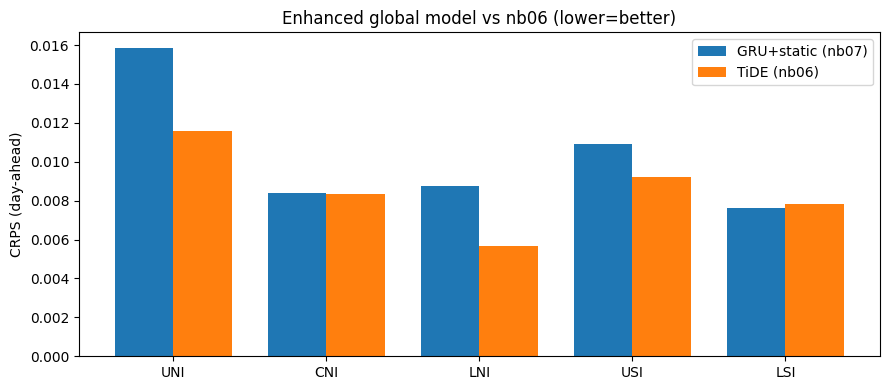

In [3]:
gbtq = {}
rows = []
for z in ZONES:
    zz = Z[z]
    fc = deep.TorchForecaster(gmodel, zz["ys"], zz["Xstat"], L, DEV, zz["ymu"], zz["ysd"])
    btq = fu.backtest_quantile(fc.quantile_fn(), dfs[z], origins, QLEVELS, max_h=H)
    gbtq[z] = btq
    rows.append(fu.score_crps(btq, HORIZONS, "global_GRU+static").assign(zone=z))
new = pd.concat(rows, ignore_index=True)

old = pd.read_csv(ROOT / "data" / "processed" / "scores_global_local.csv")
old = old[old.model == "global"][["zone", "horizon", "CRPS"]].rename(columns={"CRPS": "CRPS_TiDE_nb06"})
cmp = new.pivot(index="zone", columns="horizon", values="CRPS").add_prefix("GRU_h")
cmp = cmp.join(old.pivot(index="zone", columns="horizon", values="CRPS_TiDE_nb06").add_prefix("TiDE_h"))
cmp = cmp.loc[ZONES]
print("=== CRPS: enhanced global GRU vs nb06 global TiDE (lower=better) ===")
display(cmp.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(ZONES)); w = 0.38
ax.bar(x - w/2, cmp[f"GRU_h{fu.H_DAY}"], w, label="GRU+static (nb07)")
ax.bar(x + w/2, cmp[f"TiDE_h{fu.H_DAY}"], w, label="TiDE (nb06)")
ax.set_xticks(x); ax.set_xticklabels(ZONES); ax.set_ylabel("CRPS (day-ahead)")
ax.set_title("Enhanced global model vs nb06 (lower=better)"); ax.legend()
plt.tight_layout(); plt.show()

In [4]:
# per-zone CQR offsets from the validation windows (for calibrated operational intervals)
def val_q(zz):
    Xp, Xf, Yv = deep.make_windows(zz["ys"], zz["Xstat"], starts[-nv:], L, H)
    gmodel.eval()
    with torch.no_grad():
        q = np.sort(gmodel(Xp.to(DEV), Xf.to(DEV)).cpu().numpy(), axis=1) * zz["ysd"] + zz["ymu"]
    return q, Yv.numpy() * zz["ysd"] + zz["ymu"]
n = len(starts[-nv:]); lvl = min(1.0, (1 - ALPHA) * (1 + 1 / n))
CQR = {}
for z in ZONES:
    vq, vt = val_q(Z[z])
    E = np.maximum(vq[:, I10, :] - vt, vt - vq[:, I90, :])
    CQR[z] = np.quantile(E, lvl, axis=0)        # per lead-step widening
print("computed per-zone CQR offsets; e.g. UNI mean offset =", round(CQR['UNI'].mean(), 4), "GWh")

computed per-zone CQR offsets; e.g. UNI mean offset = 0.0002 GWh


## B. 业务化预测:接真实预报天气

下面拉取**当前**数据:EMI 最近约 16 天的实际需求(提供回看窗 + 确定"现在"),以及 Open-Meteo
**预报** API 的过去+未来逐时天气。两者都缓存到 `data/raw/`,重复运行用同一快照。

In [5]:
def fetch_live_demand():
    cache = RAW / "live_demand.csv"
    if cache.exists():
        raw = pd.read_csv(cache)
    else:
        today = pd.Timestamp.now(tz=TZ).normalize()
        p = dict(DateFrom=(today - pd.Timedelta(days=16)).strftime("%Y%m%d"),
                 DateTo=today.strftime("%Y%m%d"), RegionType="ZONE", Show="Gwh", TimeScale="TP")
        r = requests.get("https://www.emi.ea.govt.nz/Wholesale/Download/DataReport/CSV/W_GD_C",
                         params=p, headers=HDRS, timeout=120); r.raise_for_status()
        txt = r.text; raw = pd.read_csv(io.StringIO(txt[txt.find("Period start"):]))
        raw.to_csv(cache, index=False)
    raw["loc"] = pd.to_datetime(raw["Period start"], format="%d/%m/%Y %H:%M:%S")
    out = {}
    for z, g in raw.groupby("Region ID"):
        idx = pd.DatetimeIndex(g["loc"].values)
        amb = ~idx.duplicated(keep="first")
        utc = idx.tz_localize(TZ, ambiguous=amb, nonexistent="shift_forward").tz_convert("UTC")
        out[z] = pd.Series(g["Demand (GWh)"].values, index=utc).sort_index()
    return out

def fetch_forecast_weather(zone, lat, lon):
    cache = RAW / f"live_weather_{zone}.csv"
    if cache.exists():
        w = pd.read_csv(cache)
    else:
        p = {"latitude": lat, "longitude": lon, "hourly": ",".join(fu.WEATHER_FEATS),
             "past_days": 16, "forecast_days": 8, "timezone": "UTC"}
        r = requests.get("https://api.open-meteo.com/v1/forecast", params=p, headers=HDRS, timeout=60)
        r.raise_for_status()
        w = pd.DataFrame(r.json()["hourly"]).rename(columns={"time": "ts"})
        w.to_csv(cache, index=False); time.sleep(1)
    w["ts"] = pd.to_datetime(w["ts"], utc=True)
    return w.set_index("ts")[fu.WEATHER_FEATS].sort_index()

live_dem = fetch_live_demand()
live_wx = {z: fetch_forecast_weather(z, *LOC[z]) for z in ZONES}
NOW = min(live_dem[z].index.max() for z in ZONES)      # latest common demand timestamp
print("NOW (latest demand, UTC):", NOW, "=", NOW.tz_convert(TZ), "NZ")
print("forecast weather covers:", live_wx['UNI'].index.min(), "->", live_wx['UNI'].index.max())

NOW (latest demand, UTC): 2026-06-23 02:30:00+00:00 = 2026-06-23 14:30:00+12:00 NZ
forecast weather covers: 2026-06-07 00:00:00+00:00 -> 2026-06-30 23:00:00+00:00


In [6]:
# assemble the operational covariate matrices and run the model forward from NOW
nz_hol = holidays.NewZealand(years=range(2025, 2028))

def build_calendar(idx_utc):
    loc = idx_utc.tz_convert(TZ); tod = loc.hour + loc.minute / 60.0
    return np.column_stack([
        np.sin(2*np.pi*tod/24), np.cos(2*np.pi*tod/24),
        np.sin(2*np.pi*loc.dayofweek/7), np.cos(2*np.pi*loc.dayofweek/7),
        np.sin(2*np.pi*loc.dayofyear/365.25), np.cos(2*np.pi*loc.dayofyear/365.25),
        (loc.dayofweek >= 5).astype(float),
        np.array([d in nz_hol for d in loc.date], float)]).astype("f4")

# common 30-min UTC grid: L lookback steps ending at NOW, then H future steps
grid = pd.date_range(NOW - pd.Timedelta(minutes=30*(L-1)), NOW + pd.Timedelta(minutes=30*H), freq="30min", tz="UTC")
fut_idx = grid[L:L+H]

def operational(z, temp_delta=0.0):
    zz = Z[z]
    # weather on the 30-min grid (hourly forecast interpolated); optional scenario shift
    wx = live_wx[z].reindex(live_wx[z].index.union(grid)).interpolate("time").reindex(grid)
    wx = wx.copy()
    if temp_delta:
        for c in ["temperature_2m", "apparent_temperature", "dew_point_2m"]:
            wx[c] = wx[c] + temp_delta
    weather = wx[fu.WEATHER_FEATS].values.astype("f4")
    cal = build_calendar(grid)
    cov16 = np.concatenate([weather, cal], axis=1)
    Xs = (cov16 - zz["xmu"]) / zz["xsd"]
    Xstat = np.concatenate([Xs, np.tile(zz["static"], (len(grid), 1))], axis=1).astype("f4")
    # demand lookback (actual) on the grid; future unknown
    dem = live_dem[z].reindex(grid[:L])
    ys_live = np.zeros(len(grid), "f4")
    ys_live[:L] = ((dem.interpolate().bfill().ffill().values) - zz["ymu"]) / zz["ysd"]
    fc = deep.TorchForecaster(gmodel, ys_live, Xstat, L, DEV, zz["ymu"], zz["ysd"])
    q = fc.quantile_fn()(None, L - 1, H)        # (n_quantiles, H) in GWh
    return np.sort(q, axis=0)

base = {z: operational(z) for z in ZONES}
print("forward forecast built for", len(base), "zones | horizon", H, "steps (7 days) from NOW")
print("UNI next-day mean demand forecast (P50):", round(base['UNI'][I50, :fu.H_DAY].mean(), 3), "GWh/period")

forward forecast built for 5 zones | horizon 336 steps (7 days) from NOW
UNI next-day mean demand forecast (P50): 0.712 GWh/period


## B1. 前瞻预测可视化(全国 + 示例区域,带 80% 区间 CQR 校准)

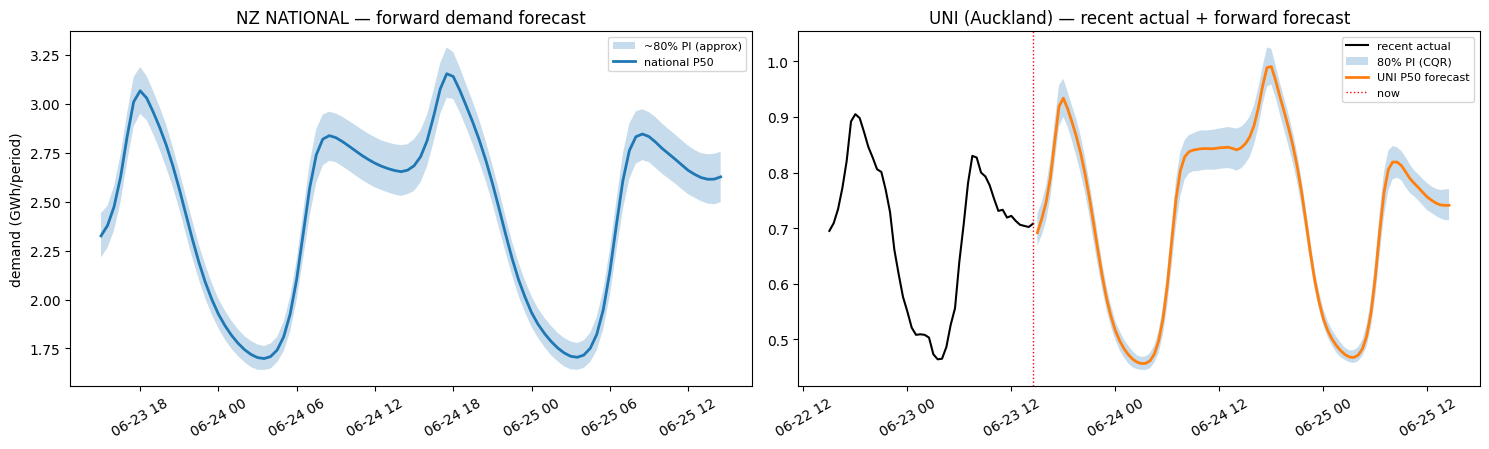

national next-day total demand (P50): 116.1 GWh


In [7]:
fut_loc = fut_idx.tz_convert(TZ)
hh = fu.H_DAY * 2          # show ~2 days of the forward forecast

def band(z):
    lo = base[z][I10] - CQR[z]; hi = base[z][I90] + CQR[z]; return base[z][I50], lo, hi

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
# national (sum of zones)
nat_p50 = sum(base[z][I50] for z in ZONES)
nat_lo = sum(base[z][I10] - CQR[z] for z in ZONES); nat_hi = sum(base[z][I90] + CQR[z] for z in ZONES)
axes[0].fill_between(fut_loc[:hh], nat_lo[:hh], nat_hi[:hh], alpha=0.25, label="~80% PI (approx)")
axes[0].plot(fut_loc[:hh], nat_p50[:hh], lw=2, label="national P50")
axes[0].set_title("NZ NATIONAL — forward demand forecast"); axes[0].legend(fontsize=8)
axes[0].set_ylabel("demand (GWh/period)")
# UNI with recent actual
p50, lo, hi = band("UNI")
look = live_dem["UNI"].reindex(grid[L-fu.H_DAY:L]).tz_convert(TZ) if hasattr(live_dem['UNI'].index,'tz') else None
axes[1].plot(grid[L-fu.H_DAY:L].tz_convert(TZ), live_dem["UNI"].reindex(grid[L-fu.H_DAY:L]).values,
             "k-", lw=1.5, label="recent actual")
axes[1].fill_between(fut_loc[:hh], lo[:hh], hi[:hh], alpha=0.25, label="80% PI (CQR)")
axes[1].plot(fut_loc[:hh], p50[:hh], lw=2, color="C1", label="UNI P50 forecast")
axes[1].axvline(NOW.tz_convert(TZ), color="r", ls=":", lw=1, label="now")
axes[1].set_title("UNI (Auckland) — recent actual + forward forecast"); axes[1].legend(fontsize=8)
for ax in axes: ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()
print("national next-day total demand (P50):", round(nat_p50[:fu.H_DAY].sum(), 1), "GWh")

## B2. 天气情景:全国需求对 ±5°C 的敏感性

把未来预报温度整体 +5°C / −5°C,重新预测,观察全国需求曲线如何移动。

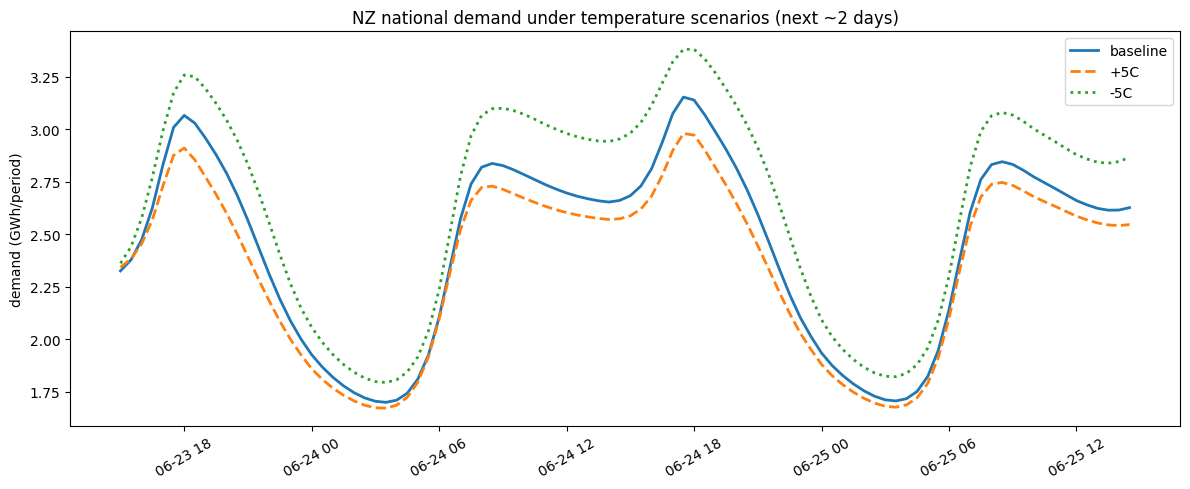

national next-day demand change under +5C: -3.5%
national next-day demand change under -5C: +8.0%


In [8]:
scen = {}
for dz, lab in [(0, "baseline"), (5, "+5C"), (-5, "-5C")]:
    scen[lab] = sum(operational(z, temp_delta=dz)[I50] for z in ZONES)

fig, ax = plt.subplots(figsize=(12, 5))
for lab, ls in [("baseline", "-"), ("+5C", "--"), ("-5C", ":")]:
    ax.plot(fut_loc[:hh], scen[lab][:hh], ls, lw=2, label=lab)
ax.set_title("NZ national demand under temperature scenarios (next ~2 days)")
ax.set_ylabel("demand (GWh/period)"); ax.legend(); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()
for lab in ["+5C", "-5C"]:
    d = (scen[lab][:fu.H_DAY].sum() - scen["baseline"][:fu.H_DAY].sum()) / scen["baseline"][:fu.H_DAY].sum()
    print(f"national next-day demand change under {lab}: {d*100:+.1f}%")

In [9]:
# save the forward forecast table (national + per zone, P10/P50/P90 with CQR)
recs = []
for z in ZONES:
    p50, lo, hi = band(z)
    for k in range(H):
        recs.append({"zone": z, "ts_utc": fut_idx[k], "p10": lo[k], "p50": p50[k], "p90": hi[k]})
fwd = pd.DataFrame(recs)
fwd.to_csv(ROOT / "data" / "processed" / "operational_forecast.csv", index=False)
print("saved operational_forecast.csv |", len(fwd), "rows |", fwd.ts_utc.min(), "->", fwd.ts_utc.max())
fwd.head()

saved operational_forecast.csv | 1680 rows | 2026-06-23 03:00:00+00:00 -> 2026-06-30 02:30:00+00:00


,zone,ts_utc,p10,p50,p90
0,UNI,2026-06-23 03:00:00+00:00,0.668204,0.691681,0.725967
1,UNI,2026-06-23 03:30:00+00:00,0.686409,0.716404,0.746063
2,UNI,2026-06-23 04:00:00+00:00,0.712675,0.745804,0.775979
3,UNI,2026-06-23 04:30:00+00:00,0.753895,0.790142,0.823590
4,UNI,2026-06-23 05:00:00+00:00,0.819170,0.855644,0.890920


---
### 小结
- **A. 增强全局模型**:全局 **GRU + 区域静态特征**(纬度/经度/规模/Tiwai)与 nb06 全局 TiDE 相比,
  **周前(336 步)CRPS 在全部 5 区都更低**(长 horizon 明显提升);**日前(48 步)略逊于 TiDE**(5 区中 4 区)。
  这与全程一致——GRU 擅长长程、TiDE/XGBoost 在超短程略占优。由于业务化预测面向多日(7 天),**选 GRU 作生产模型合理**;
  若只要日前可保留 TiDE/XGBoost。两者都只需 **1 个模型**服务全区。
- **B. 业务化预测**:用 **Open-Meteo 预报天气** + **EMI 最新需求**,从"现在"(EMI 最新时点)向前输出未来
  1 天/1 周的**带 CQR 校准区间**的需求预测(各区 + 全国);全国次日总需求 ≈116 GWh(量级合理)。
  **±5°C 情景**:全国次日需求 +5°C → 约 −3.5%、−5°C → 约 +8.0%(冬季供暖驱动、且降温的拉升更陡——方向与不对称都合理)。
  这是真正的**前瞻预测**(非回测),直接服务"不同天气情景下的需求预测"目标。结果存 `data/processed/operational_forecast.csv`。

工程化建议:① 生产环境定期(如每日)重训 + 滚动校准;② 增量缓存 EMI 与预报天气;
③ 监控前瞻预测对照后续实际、动态调整 CQR;④ 增加更多区域静态/日历特征(学期、重大赛事等)。
注:全国区间是各区 P10/P90 相加的**近似**(未建模区域间相关性),偏保守。